# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

### Исходные данные  ####
Исследуемая функция: $ f(x) = 2x^2_1 + 2x_1x_2 + 3x^2_2 - 10x_1 - 10x_2 + 15 $;

Промежуток: $ [-2, 2] $


### Определим реализацию нашей функции. Построим ее графическое представление ###

In [240]:
import numpy as np
import matplotlib.pyplot as plt

In [241]:
def f(_x1, _x2):
    """
    Квадратичная функция: f(x1, x2) = 2x1^2 + 2x1x2 + 3x2^2 - 10x1 - 10x2 + 15

    Параметры:
    x1, x2 : float или array-like
        Входные переменные

    Возвращает:
    float или array-like
        Значение функции
    """
    return 2*_x1**2 + 2*_x1*_x2 + 3*_x2**2 - 10*_x1 - 10*_x2 + 15

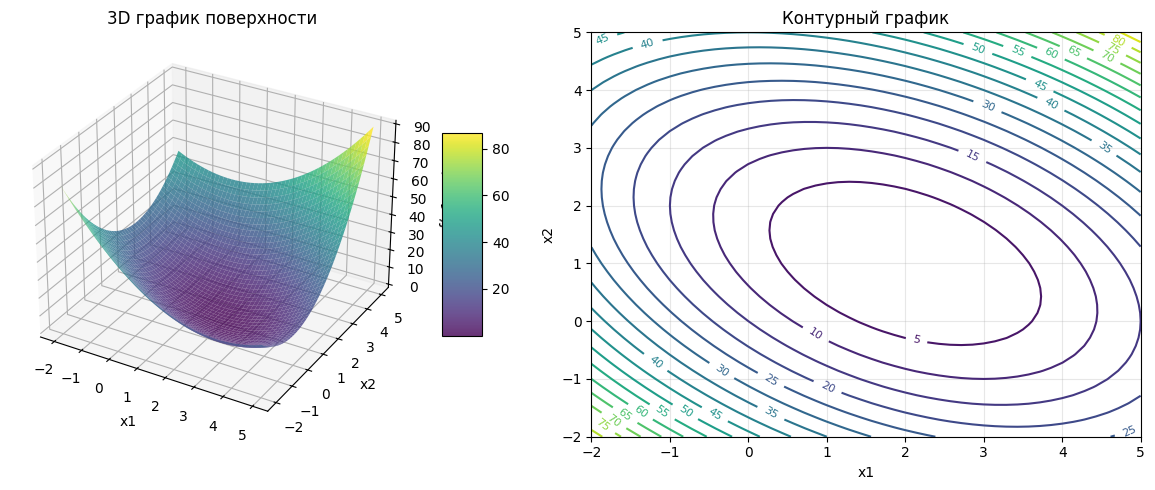

In [242]:
# Визуализация функции
x1_vals = np.linspace(-2, 5, 50)
x2_vals = np.linspace(-2, 5, 50)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

fig = plt.figure(figsize=(12, 5))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D график поверхности')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Контурный график')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Нахождение экстремумов аналитическим способом ###

Для функции двух переменных $f(x_1, x_2)$ экстремумы находятся через:

1. #### Необходимое условие экстремума

    В точке экстремума функции двух переменных все её частные производные первого порядка равны нулю:

    $$\begin{cases}
    \frac{\partial f}{\partial x_1} = 0 \\[10pt]
    \frac{\partial f}{\partial x_2} = 0
    \end{cases}$$

    Точки, удовлетворяющие этой системе, называются **стационарными**. В этих точках возможен экстремум, но не обязательно.

2. #### Достаточное условие экстремума

    Для определения типа стационарной точки вычисляются вторые частные производные:

    $$A = \frac{\partial^2 f}{\partial x_1^2}, \quad
    B = \frac{\partial^2 f}{\partial x_1 \partial x_2}, \quad
    C = \frac{\partial^2 f}{\partial x_2^2}$$

    Вычисляется дискриминант (гессиан):

    $$\Delta = AC - B^2$$

    **Правило определения типа экстремума:**

    | Условие                | Тип точки                             |
    |------------------------|---------------------------------------|
    | $\Delta > 0$ и $A > 0$ | **Локальный минимум**                 |
    | $\Delta > 0$ и $A < 0$ | **Локальный максимум**                |
    | $\Delta < 0$           | **Седловая точка** (не экстремум)     |
    | $\Delta = 0$           | Требуется дополнительное исследование |

3. #### Матрица Гессе

    Матрица Гессе (гессиан) составляется из вторых частных производных:

    $$H = \begin{pmatrix}
    \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} \\[10pt]
    \frac{\partial^2 f}{\partial x_1 \partial x_2} & \frac{\partial^2 f}{\partial x_2^2}
    \end{pmatrix} = \begin{pmatrix}
    A & B \\
    B & C
    \end{pmatrix}$$

    **Критерий Сильвестра:**
    - Если все главные миноры матрицы Гессе положительны ($A > 0$, $\Delta > 0$) — точка минимума
    - Если главные миноры знакочередуются ($A < 0$, $\Delta > 0$) — точка максимума

4.  #### Алгоритм исследования

    1. Найти частные производные первого порядка $\frac{\partial f}{\partial x_1}$ и $\frac{\partial f}{\partial x_2}$
    2. Решить систему уравнений $\frac{\partial f}{\partial x_1} = 0$, $\frac{\partial f}{\partial x_2} = 0$ для нахождения стационарных точек
    3. Найти частные производные второго порядка $A$, $B$, $C$
    4. Для каждой стационарной точки вычислить значения $A$, $B$, $C$ и $\Delta$
    5. По знаку $\Delta$ и $A$ определить тип экстремума
    6. Вычислить значение функции в точках экстремума


ИССЛЕДОВАНИЕ ФУНКЦИИ НА ЭКСТРЕМУМЫ

Функция: f(x1, x2) = 2*x1**2 + 2*x1*x2 - 10*x1 + 3*x2**2 - 10*x2 + 15

1. ЧАСТНЫЕ ПРОИЗВОДНЫЕ ПЕРВОГО ПОРЯДКА:
   ∂f/∂x1 = 4*x1 + 2*x2 - 10
   ∂f/∂x2 = 2*x1 + 6*x2 - 10

2. СТАЦИОНАРНЫЕ ТОЧКИ:
   Решаем систему:
   4*x1 + 2*x2 - 10 = 0
   2*x1 + 6*x2 - 10 = 0

   Стационарные точки:
   x1 = 2, x2 = 1

3. ВТОРЫЕ ЧАСТНЫЕ ПРОИЗВОДНЫЕ:
   A = ∂²f/∂x1² = 4
   B = ∂²f/∂x1∂x2 = 2
   C = ∂²f/∂x2² = 6

4. ИССЛЕДОВАНИЕ ТИПА ЭКСТРЕМУМА:
------------------------------------------------------------

Точка 1: (2, 1)
  Значение функции: f = 0
  A = 4, B = 2, C = 6
  Δ = AC - B² = 20
  → ТОЧКА МИНИМУМА (локальный минимум)

ВЫВОД:

✓ В точке (2, 1) функция имеет ЛОКАЛЬНЫЙ МИНИМУМ
  f_min = 0

ВИЗУАЛИЗАЦИЯ:


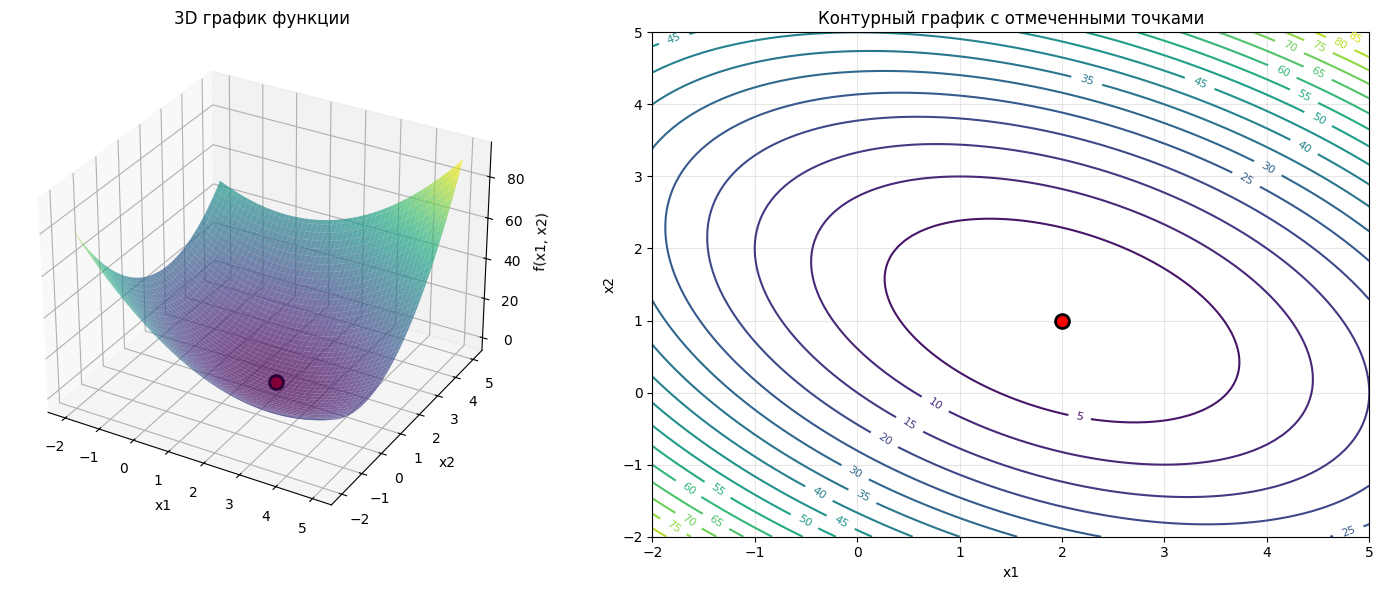


ТОЧНЫЙ АНАЛИТИЧЕСКИЙ РЕЗУЛЬТАТ:

Градиент функции: ∇f = (4*x1 + 2*x2 - 10, 2*x1 + 6*x2 - 10)

Матрица Гессе (гессиан):
⎡4  2⎤
⎢    ⎥
⎣2  6⎦

Собственные значения матрицы Гессе: {5 - sqrt(5): 1, sqrt(5) + 5: 1}
→ Матрица Гессе положительно определена, функция строго выпуклая
→ Найденная стационарная точка является ГЛОБАЛЬНЫМ минимумом


In [243]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Определяем символические переменные
x1, x2 = sp.symbols('x1 x2')

# Задаем функцию
y = 2*x1**2 + 2*x1*x2 + 3*x2**2 - 10*x1 - 10*x2 + 15

print("=" * 60)
print("ИССЛЕДОВАНИЕ ФУНКЦИИ НА ЭКСТРЕМУМЫ")
print("=" * 60)
print(f"\nФункция: f(x1, x2) = {y}")
print()

# 1. Находим частные производные первого порядка
f_x1 = sp.diff(y, x1)
f_x2 = sp.diff(y, x2)

print("1. ЧАСТНЫЕ ПРОИЗВОДНЫЕ ПЕРВОГО ПОРЯДКА:")
print(f"   ∂f/∂x1 = {f_x1}")
print(f"   ∂f/∂x2 = {f_x2}")
print()

# 2. Решаем систему уравнений для нахождения стационарных точек
print("2. СТАЦИОНАРНЫЕ ТОЧКИ:")
print("   Решаем систему:")
print(f"   {f_x1} = 0")
print(f"   {f_x2} = 0")
print()

# Решаем систему уравнений
solution = sp.solve([f_x1, f_x2], [x1, x2])

# Проверяем тип решения и извлекаем точки
if isinstance(solution, dict):
    # Если решение в виде словаря
    stationary_points = [(solution[x1], solution[x2])]
elif isinstance(solution, list):
    # Если решение в виде списка кортежей
    stationary_points = solution
else:
    stationary_points = [solution]

print("   Стационарные точки:")
for point in stationary_points:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        print(f"   x1 = {point[0]}, x2 = {point[1]}")
    else:
        print(f"   x1 = {point[0] if isinstance(point, (tuple, list)) else point}, x2 = {point[1] if isinstance(point, (tuple, list)) else '?'}")
print()

# 3. Находим вторые частные производные
f_xx = sp.diff(f_x1, x1)  # ∂²f/∂x1²
f_xy = sp.diff(f_x1, x2)  # ∂²f/∂x1∂x2
f_yy = sp.diff(f_x2, x2)  # ∂²f/∂x2²

print("3. ВТОРЫЕ ЧАСТНЫЕ ПРОИЗВОДНЫЕ:")
print(f"   A = ∂²f/∂x1² = {f_xx}")
print(f"   B = ∂²f/∂x1∂x2 = {f_xy}")
print(f"   C = ∂²f/∂x2² = {f_yy}")
print()

# 4. Исследуем каждую стационарную точку
print("4. ИССЛЕДОВАНИЕ ТИПА ЭКСТРЕМУМА:")
print("-" * 60)

# Преобразуем стационарные точки в список для единообразия
points_list = []
if isinstance(stationary_points, dict):
    points_list = [(stationary_points[x1], stationary_points[x2])]
elif isinstance(stationary_points, list):
    points_list = stationary_points
else:
    points_list = [(stationary_points, stationary_points)] if stationary_points else []

for i, point in enumerate(points_list, 1):
    # Извлекаем значения x1 и x2
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    # Вычисляем значения вторых производных в точке
    A_val = f_xx.subs({x1: x1_val, x2: x2_val})
    B_val = f_xy.subs({x1: x1_val, x2: x2_val})
    C_val = f_yy.subs({x1: x1_val, x2: x2_val})

    # Вычисляем дискриминант
    Delta = A_val * C_val - B_val**2

    # Вычисляем значение функции в точке
    f_val = y.subs({x1: x1_val, x2: x2_val})

    print(f"\nТочка {i}: ({x1_val}, {x2_val})")
    print(f"  Значение функции: f = {f_val}")
    print(f"  A = {A_val}, B = {B_val}, C = {C_val}")
    print(f"  Δ = AC - B² = {Delta}")

    # Определяем тип точки
    if Delta > 0:
        if A_val > 0:
            print(f"  → ТОЧКА МИНИМУМА (локальный минимум)")
        elif A_val < 0:
            print(f"  → ТОЧКА МАКСИМУМА (локальный максимум)")
    elif Delta < 0:
        print(f"  → СЕДЛОВАЯ ТОЧКА (не является экстремумом)")
    else:
        print(f"  → ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНОЕ ИССЛЕДОВАНИЕ (Δ = 0)")

print("\n" + "=" * 60)
print("ВЫВОД:")
print("=" * 60)

for i, point in enumerate(points_list, 1):
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    f_val = y.subs({x1: x1_val, x2: x2_val})

    A_val = f_xx.subs({x1: x1_val, x2: x2_val})
    B_val = f_xy.subs({x1: x1_val, x2: x2_val})
    C_val = f_yy.subs({x1: x1_val, x2: x2_val})
    Delta = A_val * C_val - B_val**2

    if Delta > 0 and A_val > 0:
        print(f"\n✓ В точке ({x1_val}, {x2_val}) функция имеет ЛОКАЛЬНЫЙ МИНИМУМ")
        print(f"  f_min = {f_val}")
    elif Delta > 0 > A_val:
        print(f"\n✓ В точке ({x1_val}, {x2_val}) функция имеет ЛОКАЛЬНЫЙ МАКСИМУМ")
        print(f"  f_max = {f_val}")
    elif Delta < 0:
        print(f"\n✗ В точке ({x1_val}, {x2_val}) седловая точка (экстремума нет)")

# Визуализация для наглядности
print("\n" + "=" * 60)
print("ВИЗУАЛИЗАЦИЯ:")
print("=" * 60)

# Создаем сетку для построения графиков
x1_vals = np.linspace(-2, 5, 100)
x2_vals = np.linspace(-2, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Преобразуем символьную функцию в числовую
f_numeric = sp.lambdify((x1, x2), y, 'numpy')
Z = f_numeric(X1, X2)

# Создаем фигуру с двумя под-графиками
fig = plt.figure(figsize=(15, 6))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7, edgecolor='none')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D график функции')

# Отмечаем стационарные точки
for point in points_list:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    z_val = f_numeric(float(str(x1_val)), float(str(x2_val)))
    ax1.scatter(float(str(x1_val)), float(str(x2_val)), float(z_val),
               color='red', s=100, edgecolor='black', linewidth=2)

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Контурный график с отмеченными точками')
ax2.grid(True, alpha=0.3)

# Отмечаем стационарные точки на контурном графике
for point in points_list:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    ax2.scatter(float(str(x1_val)), float(str(x2_val)), color='red', s=100,
               edgecolor='black', linewidth=2, zorder=5)

plt.tight_layout()
plt.show()

# Дополнительный анализ: находим точное значение минимума
print("\n" + "=" * 60)
print("ТОЧНЫЙ АНАЛИТИЧЕСКИЙ РЕЗУЛЬТАТ:")
print("=" * 60)

# Находим градиент
gradient = [f_x1, f_x2]
print(f"\nГрадиент функции: ∇f = ({gradient[0]}, {gradient[1]})")

# Находим матрицу Гессе
hessian = sp.Matrix([[f_xx, f_xy], [f_xy, f_yy]])
print(f"\nМатрица Гессе (гессиан):")
sp.pprint(hessian)

# Определяем, является ли матрица положительно определенной
eigenvalues = hessian.eigenvals()
print(f"\nСобственные значения матрицы Гессе: {eigenvalues}")

if all(ev > 0 for ev in eigenvalues.keys()):
    print("→ Матрица Гессе положительно определена, функция строго выпуклая")
    print("→ Найденная стационарная точка является ГЛОБАЛЬНЫМ минимумом")
elif all(ev < 0 for ev in eigenvalues.keys()):
    print("→ Матрица Гессе отрицательно определена, функция строго вогнутая")
    print("→ Найденная стационарная точка является ГЛОБАЛЬНЫМ максимумом")

Таким образом, аналитическими методами была найдена 1 точка экстремума (2, 1) - точка минимума (глобального, согласно оценке по гессиану)

### Нахождение экстремумов численными способами ###
В большинстве случаев использовать аналитические способы невозможно ввиду сложности дифференцирования самой функции либо ее большой многомерности.

В первом случае применяют методы прямого поиска минимума целевой функции (или методы _нулевого порядка_), в которых используют информацию только о значениях этой функции, а для второго случая, при условии дифференцируемости функции n-раз, используют методы _n-го порядка_.

Также обычно берут некоторую начальную точку для первой итерации:

$ x_0 $ = (-2, -2)

In [244]:
# Критерий остановки epsilon
epsilon = 0.0001

# Начальная точка
x0 = (-2, -2)

#### Метод по-координатного спуска ####

##### Идея

Минимизация функции нескольких переменных выполняется поочередно по каждой координате, фиксируя остальные.

---

##### Алгоритм

Пусть текущая точка:
$
x^k = (x_1^k, x_2^k, \dots, x_n^k)
$

На каждой итерации:

1. Минимизируем по ($x_1$), фиксируя остальные:
   $
   (x_1^{k+1}, x_2^k, \dots, x_n^k)
   $

2. Минимизируем по ($x_2$), фиксируя остальные:
   $
   (x_1^{k+1}, x_2^{k+1}, \dots, x_n^k)
   $

3. Повторяем для всех координат до ($x_n$)

После прохода по всем координатам получаем:
$
x^{k+1} = (x_1^{k+1}, x_2^{k+1}, \dots, x_n^{k+1})
$

---

##### Критерий остановки

$
|x^{k+1} - x^k| \le \varepsilon
$
или
$
|f(x^{k+1}) - f(x^k)| \le \varepsilon
$

---

##### Геометрический смысл

Движение происходит поочередно вдоль координатных осей → траектория имеет вид «зигзага».

---

##### Ключевые свойства

* сводит многомерную задачу к одномерным
* прост в реализации
* медленная сходимость (зигзагообразное движение)

---

##### Одномерная минимизация

Для каждой координаты в качестве метода одномерной минимизации будем использовать _метод золотого сечения_

МЕТОД ПО-КООРДИНАТНОГО СПУСКА
f(x1, x2) = 2x1^2 + 2x1x2 + 3x2^2 - 10x1 - 10x2 + 15

Начальная точка: (-2, -2)

Результат:
  Точка минимума: (2.000020, 1.000007)
  Значение функции: 0.000000
  Количество итераций: 8


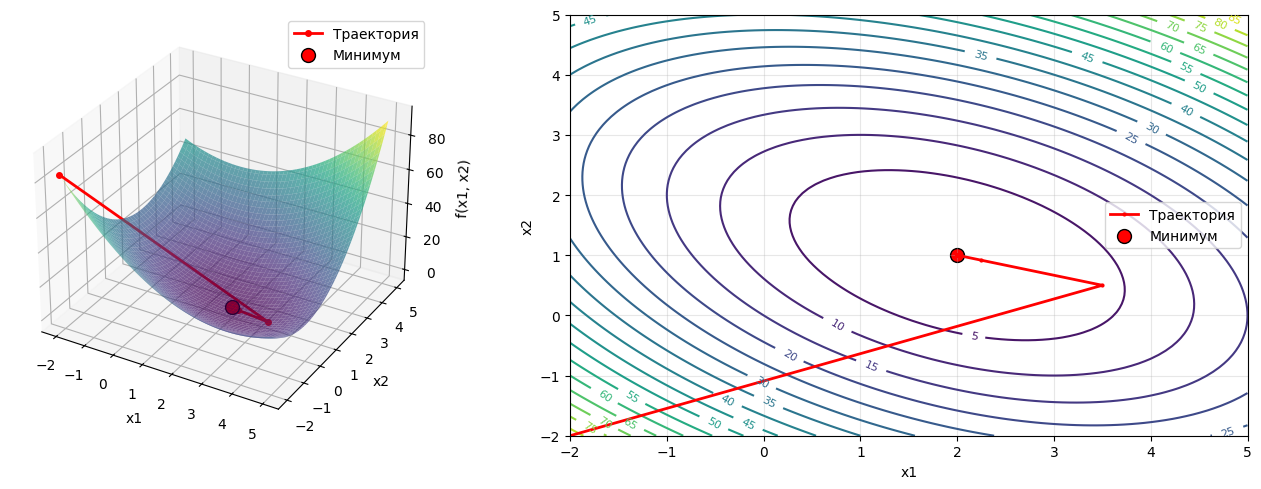

In [245]:
from typing import Optional, Callable

# Глобальная функция, которую будем минимизировать
current_func: Optional[Callable[[float], float]] = None

def set_function(func):
    """Устанавливаем текущую функцию для золотого сечения"""
    global current_func
    current_func = func

# Метод золотого сечения для одномерно оптимизации из лаб. №2
def golden_section_search(_f: Callable[[float], float], a: float, b: float, eps: float):
    phi = (1 + 5 ** 0.5) / 2
    res_phi = 2 - phi  # ≈ 0.382

    _x1 = a + res_phi * (b - a)
    _x2 = b - res_phi * (b - a)

    f1 = _f(_x1)
    f2 = _f(_x2)

    while abs(b - a) > eps:
        if f1 < f2:
            b = _x2
            _x2 = _x1
            f2 = f1
            _x1 = a + res_phi * (b - a)
            f1 = _f(_x1)
        else:
            a = _x1
            _x1 = _x2
            f1 = f2
            _x2 = b - res_phi * (b - a)
            f2 = _f(_x2)

    return (a + b) / 2

def coordinate_descent(start_point, eps=1e-6, max_iter=100):
    _x1, _x2 = start_point
    _trajectory = [(_x1, _x2, f(_x1, _x2))]

    for iteration in range(max_iter):
        _prev_x1, _prev_x2 = _x1, _x2

        _x1 = golden_section_search(lambda _x: f(_x, _x2), _x1 - 10, _x1 + 10, eps)
        _x2 = golden_section_search(lambda _x: f(_x1, _x), _x2 - 10, _x2 + 10, eps)

        _trajectory.append((_x1, _x2, f(_x1, _x2)))

        if np.sqrt((_x1 - _prev_x1)**2 + (_x2 - _prev_x2)**2) < eps:
            break

    return _x1, _x2, f(_x1, _x2), _trajectory

# Поиск минимума
x1_min, x2_min, f_min, trajectory = coordinate_descent(x0, epsilon, 100)

print("МЕТОД ПО-КООРДИНАТНОГО СПУСКА")
print(f"f(x1, x2) = 2x1^2 + 2x1x2 + 3x2^2 - 10x1 - 10x2 + 15\n")
print(f"Начальная точка: ({x0[0]}, {x0[1]})")
print(f"\nРезультат:")
print(f"  Точка минимума: ({x1_min:.6f}, {x2_min:.6f})")
print(f"  Значение функции: {f_min:.6f}")
print(f"  Количество итераций: {len(trajectory) - 1}")

# Визуализация
x1_vals = np.linspace(-2, 5, 100)
x2_vals = np.linspace(-2, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

fig = plt.figure(figsize=(14, 5))

# 3D график
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)
traj = np.array(trajectory)
ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'r-o', markersize=4, linewidth=2, label='Траектория')
ax1.scatter(x1_min, x2_min, f_min, color='red', s=100, edgecolor='black', label='Минимум')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.legend()

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(traj[:, 0], traj[:, 1], 'r-o', markersize=2, linewidth=2, label='Траектория')
ax2.scatter(x1_min, x2_min, color='red', s=100, edgecolor='black', label='Минимум')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

#### Градиентный метод

##### Идея

Используем градиент функции для построения направления спуска.

Градиентные методы — это класс методов, использующих первую производную.

---

##### Градиент

$
\nabla f(x) = \left( \frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_n} \right)
$

---

##### Алгоритм

Пусть начальная точка:
$
x^{(0)}
$

На k-й итерации:

1. Вычисляем градиент:
   $
   \nabla f(x^{(k)})
   $

2. Делаем шаг против градиента:
   $
   x^{(k+1)} = x^{(k)} - \alpha^{(k)} \nabla f(x^{(k)})
   $

3. Повторяем для k = 0,1,2,...

---

##### Критерий остановки

$
|x^{(k+1)} - x^{(k)}| \le \varepsilon
$
или
$
|\nabla f(x^{(k)})| \le \varepsilon
$

---

##### Геометрический смысл

* градиент → направление наибольшего роста
* движение против него → наискорейший спуск

---

##### Особенности

* использует только первые производные
* на каждом шаге используется информация о градиенте

---

##### Недостатки

* медленная сходимость в «оврагах»
* возможны колебания

---

##### Параметры
Для градиентного метода необходимо задать шаг итерации, который показывает, насколько далеко мы двигаемся в направлении антиградиента. Для нашей функции можно вычислить оптимальное значение через собственные числа гессиана, который мы нашли ранее:

$ \alpha = \frac{2}{\lambda_{min} + \lambda_{max}} $
$ \alpha = \frac{2}{5 - \sqrt{5} + 5 + \sqrt{5}} = 0.2 $


In [246]:
# Шаг итерации
step = 0.2

ГРАДИЕНТНЫЙ МЕТОД (с постоянным шагом)
f(x1, x2) = 2x1² + 2x1x2 + 3x2² - 10x1 - 10x2 + 15

Начальная точка: (-2, -2)
Шаг (learning rate): 0.2

Результат:
  Точка минимума: (2.000005, 1.000028)
  Значение функции: 0.000000
  Количество итераций: 15


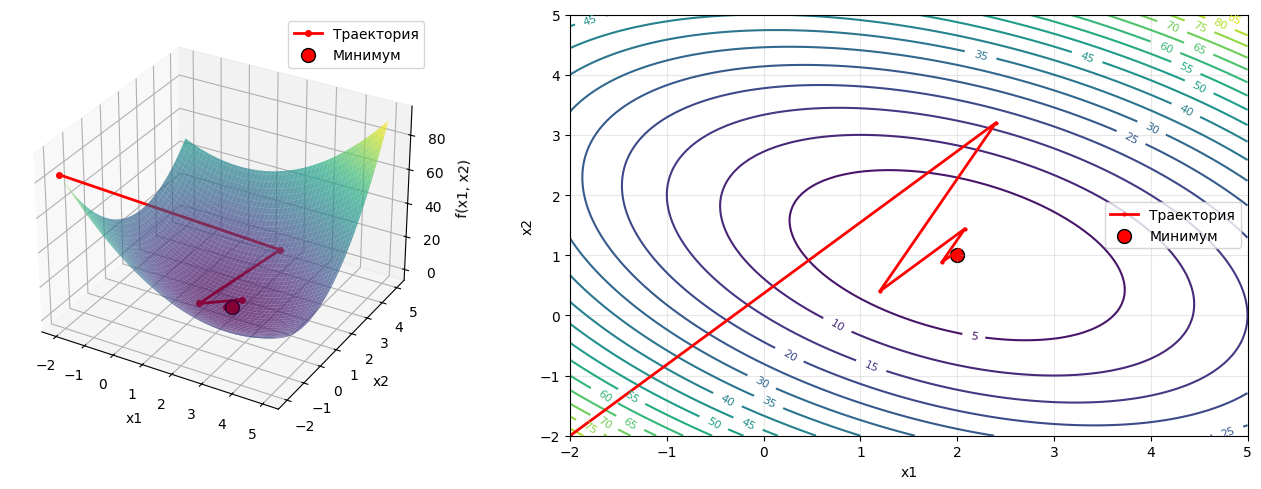

In [247]:
def gradient(_x1, _x2):
    """Вычисление градиента функции"""
    grad_x1 = 4*_x1 + 2*_x2 - 10
    grad_x2 = 2*_x1 + 6*_x2 - 10
    return grad_x1, grad_x2

def gradient_descent(start_point, learning_rate, max_iter=100):
    """
    Градиентный метод с постоянным шагом (без наискорейшего спуска)

    Параметры:
    start_point - начальная точка (x1, x2)
    learning_rate - шаг градиентного спуска (постоянный)
    eps - точность остановки
    max_iter - максимальное количество итераций

    Возвращает:
    x1, x2 - координаты точки минимума
    f_min - значение функции в точке минимума
    trajectory - траектория движения (список точек)
    """
    _x1, _x2 = start_point
    _trajectory = [(_x1, _x2, f(_x1, _x2))]

    for iteration in range(max_iter):
        x1_prev, x2_prev = _x1, _x2

        # Вычисляем градиент в текущей точке
        grad_x1, grad_x2 = gradient(_x1, _x2)

        # Делаем шаг в направлении антиградиента
        _x1 = _x1 - learning_rate * grad_x1
        _x2 = _x2 - learning_rate * grad_x2

        _trajectory.append((_x1, _x2, f(_x1, _x2)))

        # Проверка условия остановки
        if np.sqrt((_x1 - x1_prev)**2 + (_x2 - x2_prev)**2) < epsilon:
            break

    return _x1, _x2, f(_x1, _x2), _trajectory

# Запуск градиентного метода
x1_min, x2_min, f_min, trajectory = gradient_descent(x0, step)

# Вывод результатов
print("ГРАДИЕНТНЫЙ МЕТОД (с постоянным шагом)")
print(f"f(x1, x2) = 2x1² + 2x1x2 + 3x2² - 10x1 - 10x2 + 15\n")
print(f"Начальная точка: ({x0[0]}, {x0[1]})")
print(f"Шаг (learning rate): {learning_step}")
print(f"\nРезультат:")
print(f"  Точка минимума: ({x1_min:.6f}, {x2_min:.6f})")
print(f"  Значение функции: {f_min:.6f}")
print(f"  Количество итераций: {len(trajectory) - 1}")

# Визуализация
x1_vals = np.linspace(-2, 5, 100)
x2_vals = np.linspace(-2, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

fig = plt.figure(figsize=(14, 5))

# 3D график
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)
traj = np.array(trajectory)
ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'r-o', markersize=4, linewidth=2, label='Траектория')
ax1.scatter(x1_min, x2_min, f_min, color='red', s=100, edgecolor='black', label='Минимум')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.legend()

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(traj[:, 0], traj[:, 1], 'r-o', markersize=2, linewidth=2, label='Траектория')
ax2.scatter(x1_min, x2_min, color='red', s=100, edgecolor='black', label='Минимум')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

#### Метод наискорейшего спуска

##### Идея

Движение выполняется в направлении антиградиента с оптимальным шагом.
На каждом шаге решается задача одномерной минимизации.

---

##### Направление спуска

$
S^{(k)} = -\nabla f(x^{(k)})
$

---

##### Итерационный шаг

$
x^{(k+1)} = x^{(k)} + \lambda_k S^{(k)}
$
, где ($ \lambda_k $) — решение:
$
\min_{\lambda} f(x^{(k)} + \lambda S^{(k)})
$

---

##### Алгоритм

1. Задать $ x^{(0)} $, $ \varepsilon $
2. Вычислить $ \nabla f(x^{(k)}) $
3. Если $ |\nabla f(x^{(k)})| < \varepsilon $ → остановка
4. $ S^{(k)} = -\nabla f(x^{(k)}) $
5. Найти оптимальный шаг $ \lambda_k $
6. $ x^{(k+1)} = x^{(k)} + \lambda_k S^{(k)} $
7. Повтор

---

##### Геометрический смысл

* антиградиент — направление наискорейшего убывания
* движение происходит до минимума вдоль этого направления

---

##### Особенности

* оптимальный шаг на каждой итерации
* меньше итераций, чем в обычном градиентном методе

---

##### Недостатки

* требуется решать одномерную задачу
* возможны зигзаги

---

##### Одномерная минимизация

Для каждой координаты в качестве метода одномерной минимизации будем использовать _метод золотого сечения_

МЕТОД НАИСКОРЕЙШЕГО СПУСКА
f(x1, x2) = 2x1² + 2x1x2 + 3x2² - 10x1 - 10x2 + 15

Начальная точка: (-2, -2)

Результат:
  Точка минимума: (1.999991, 1.000006)
  Значение функции: 0.000000
  Количество итераций: 7


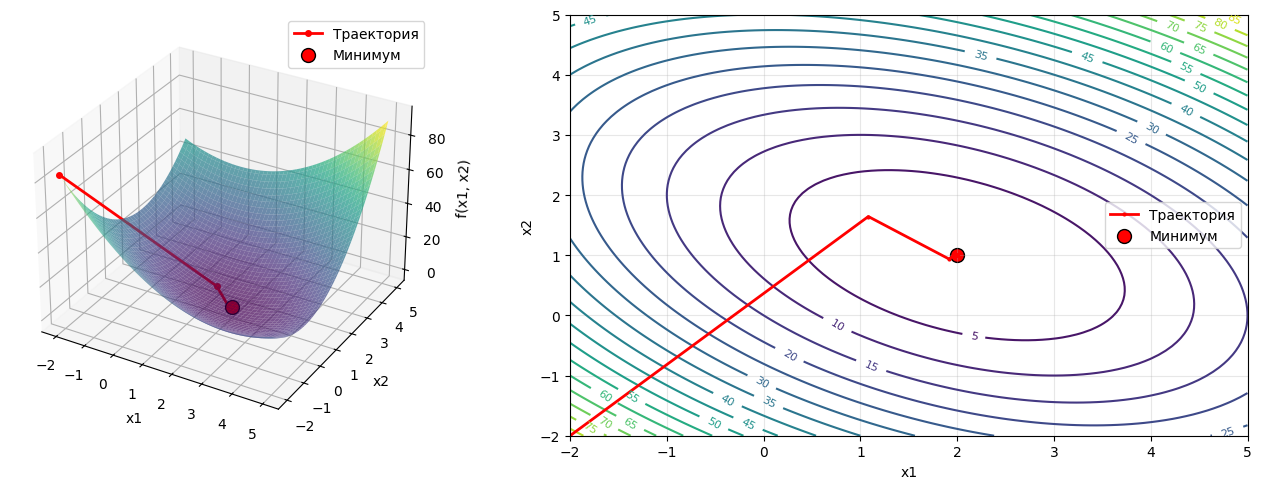

In [248]:
def norm_gradient(_x1, _x2):
    """Вычисление нормы градиента"""
    g1, g2 = gradient(_x1, _x2)
    return np.sqrt(g1**2 + g2**2)

# МЕТОД НАИСКОРЕЙШЕГО СПУСКА
def steepest_descent(start_point, max_iter=100):
    """
    Метод наискорейшего спуска

    Алгоритм:
    Шаг 0. Задать eps > 0, x0 - начальную точку. Положить k = 0.
    Шаг 1. Вычислить градиент в точке x_k. Если ||∇f(x_k)|| < eps, то конец.
    Шаг 2. Найти оптимальный шаг λ_k, решая задачу одномерной оптимизации:
           min_λ f(x_k - λ·∇f(x_k))
    Шаг 3. Вычислить новую точку: x_{k+1} = x_k - λ_k·∇f(x_k)
    Шаг 4. Положить k = k+1 и перейти на шаг 1.

    Параметры:
    start_point - начальная точка (x1, x2)
    eps - точность остановки (порог для нормы градиента)
    max_iter - максимальное количество итераций

    Возвращает:
    x1, x2 - координаты точки минимума
    f_min - значение функции в точке минимума
    trajectory - траектория движения (список точек)
    """
    _x1, _x2 = start_point
    _trajectory = [(_x1, _x2, f(_x1, _x2))]

    for iteration in range(max_iter):
        # Шаг 1: Проверка условия остановки по норме градиента
        grad_norm = norm_gradient(_x1, _x2)
        if grad_norm < epsilon:
            break

        # Шаг 2: Вычисляем направление антиградиента
        _grad_x1, _grad_x2 = gradient(_x1, _x2)

        # Находим оптимальный шаг λ_k с помощью метода золотого сечения.
        # Решаем задачу: min_λ f(x1 - λ·grad_x1, x2 - λ·grad_x2).
        # Используем динамическое определение интервала поиска.
        _lambda_opt = golden_section_search(
            lambda lmbd: f(_x1 - lmbd * _grad_x1, _x2 - lmbd * _grad_x2),
            a=0,
            b=2.0,  # начальный интервал для поиска шага (можно увеличить при необходимости)
            eps=epsilon
        )

        # Шаг 3: Вычисляем новую точку
        _x1 = _x1 - _lambda_opt * _grad_x1
        _x2 = _x2 - _lambda_opt * _grad_x2

        _trajectory.append((_x1, _x2, f(_x1, _x2)))

    return _x1, _x2, f(_x1, _x2), _trajectory

# Поиск минимума методом наискорейшего спуска
x1_min, x2_min, f_min, trajectory = steepest_descent(x0)

print("МЕТОД НАИСКОРЕЙШЕГО СПУСКА")
print(f"f(x1, x2) = 2x1² + 2x1x2 + 3x2² - 10x1 - 10x2 + 15\n")
print(f"Начальная точка: ({x0[0]}, {x0[1]})")
print(f"\nРезультат:")
print(f"  Точка минимума: ({x1_min:.6f}, {x2_min:.6f})")
print(f"  Значение функции: {f_min:.6f}")
print(f"  Количество итераций: {len(trajectory) - 1}")

# Визуализация
x1_vals = np.linspace(-2, 5, 100)
x2_vals = np.linspace(-2, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

fig = plt.figure(figsize=(14, 5))

# 3D график
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)
traj = np.array(trajectory)
ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'r-o', markersize=4, linewidth=2, label='Траектория')
ax1.scatter(x1_min, x2_min, f_min, color='red', s=100, edgecolor='black', label='Минимум')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.legend()

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(traj[:, 0], traj[:, 1], 'r-o', markersize=2, linewidth=2, label='Траектория')
ax2.scatter(x1_min, x2_min, color='red', s=100, edgecolor='black', label='Минимум')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()